In [1]:
# KEY OBSERVATION: SEQUENCES - SUCH AS SEQUENCE OF WORDS

# EXAMPLE: I FLEW FROM HEATHROW AIRPORT
# here notice that words alone have little context
# Heathrow is a county in England
# Airport is where planes land
# Flew ~ Flying: is an action
# When considering the sequence of words however we have context, meaning
# That is what RNNs strive for when learning

# Install dependencies (run once):
#  pip install numpy pandas matplotlib tensorflow keras

import collections

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import layers
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences


def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(2, 1)
    ax1.plot(history.history["loss"], label="loss")
    ax1.plot(history.history["val_loss"], label="val_loss")
    ax1.legend()
    ax2.plot(history.history["accuracy"], label="acc")
    ax2.plot(history.history["val_accuracy"], label="val_acc")
    ax2.legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

print("✅ Cell 1 Complete: Libraries loaded and graphing tool ready!")

/Users/alinakatiliute/university/BIM RSM/Deep Learning Python/venv/lib/python3.8/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


✅ Cell 1 Complete: Libraries loaded and graphing tool ready!


In [2]:
# Load IMDB data.
(train_x, train_y), (test_x, test_y) = imdb.load_data(num_words=500)
print("Train/test set sizes:", len(train_x), len(test_x))

# Take a look at train_x and train_y see how documents are represented,
# and each document contains a different number of words.
# Note: At this point we don't have a vocabulary file
# so we don't actually know what these numbers constitute to.
# But they are word_IDs.
train_counts = collections.Counter(train_y)
print(f"Train label distribution: {train_counts[0]} negative, {train_counts[1]} positive")
test_counts = collections.Counter(test_y)
print(f"Test label distribution:  {test_counts[0]} negative, {test_counts[1]} positive")

# Padding sequences.
train_x = pad_sequences(train_x, maxlen=200)
test_x = pad_sequences(test_x, maxlen=200)

print("✅ Cell 2 Complete: Data loaded and padded!")

Train/test set sizes: 25000 25000
Train label distribution: 12500 negative, 12500 positive
Test label distribution:  12500 negative, 12500 positive
✅ Cell 2 Complete: Data loaded and padded!



--------------------------------------------------
Model 1
--------------------------------------------------
Epoch 1/10
157/157 [==============================] - 5s 25ms/step - loss: 0.6272 - accuracy: 0.6639 - val_loss: 0.5545 - val_accuracy: 0.7710
Epoch 2/10
157/157 [==============================] - 4s 26ms/step - loss: 0.5293 - accuracy: 0.7624 - val_loss: 0.5139 - val_accuracy: 0.7698
Epoch 3/10
157/157 [==============================] - 3s 19ms/step - loss: 0.4840 - accuracy: 0.7850 - val_loss: 0.5095 - val_accuracy: 0.7590
Epoch 4/10
157/157 [==============================] - 3s 20ms/step - loss: 0.4556 - accuracy: 0.8013 - val_loss: 0.4961 - val_accuracy: 0.7548
Epoch 5/10
157/157 [==============================] - 4s 26ms/step - loss: 0.4380 - accuracy: 0.8056 - val_loss: 0.5214 - val_accuracy: 0.7588
Epoch 6/10
157/157 [==============================] - 3s 19ms/step - loss: 0.4386 - accuracy: 0.8066 - val_loss: 0.4602 - val_accuracy: 0.7890
Epoch 7/10
157/157 [===========

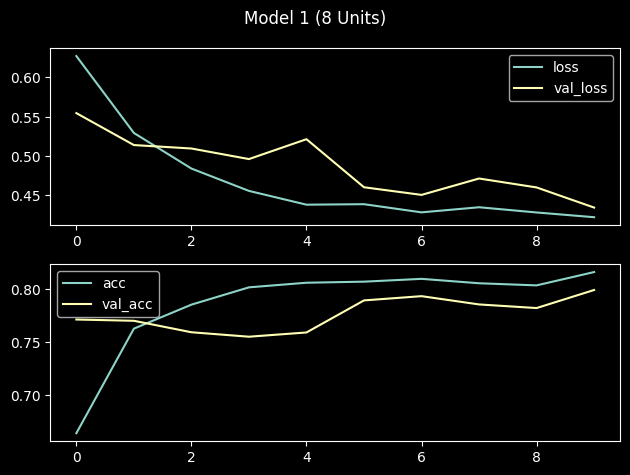

Actual         0      1
Predicted              
0.0        10389   2289
1.0         2111  10211
--- Test Predictions ---
Actual         0      1
Predicted              
0.0        10164   2496
1.0         2336  10004


In [3]:
# --- Model 1 ---
print("\n" + "-" * 50)
print("Model 1")
print("-" * 50)

model1 = keras.Sequential([
    layers.Embedding(input_dim=500, output_dim=32),
    layers.SimpleRNN(units=8),  # default activation: tanh, S-shaped [-1..1].
    layers.Dense(units=1, activation="sigmoid")
])

model1.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Fit model.
history1 = model1.fit(
    train_x, train_y,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

model1.summary()
plot_history(history1, "Model 1 (8 Units)")

# Prediction.
model1.evaluate(train_x, train_y, verbose=0)
pred = np.round(model1.predict(train_x, verbose=0)).flatten()
print(pd.crosstab(pred, train_y, rownames=["Predicted"], colnames=["Actual"]))

model1.evaluate(test_x, test_y, verbose=0)
pred1 = np.round(model1.predict(test_x, verbose=0)).flatten()
print("--- Test Predictions ---")
print(pd.crosstab(pred1, test_y, rownames=["Predicted"], colnames=["Actual"]))


--------------------------------------------------
Model 2
--------------------------------------------------
Epoch 1/10
157/157 [==============================] - 5s 28ms/step - loss: 0.6872 - accuracy: 0.5393 - val_loss: 0.6575 - val_accuracy: 0.6088
Epoch 2/10
157/157 [==============================] - 4s 27ms/step - loss: 0.5615 - accuracy: 0.7203 - val_loss: 0.6891 - val_accuracy: 0.6248
Epoch 3/10
157/157 [==============================] - 3s 21ms/step - loss: 0.4846 - accuracy: 0.7738 - val_loss: 0.4918 - val_accuracy: 0.7716
Epoch 4/10
157/157 [==============================] - 4s 23ms/step - loss: 0.4456 - accuracy: 0.7976 - val_loss: 0.4622 - val_accuracy: 0.7890
Epoch 5/10
157/157 [==============================] - 5s 29ms/step - loss: 0.4313 - accuracy: 0.8077 - val_loss: 0.5111 - val_accuracy: 0.7740
Epoch 6/10
157/157 [==============================] - 3s 22ms/step - loss: 0.4169 - accuracy: 0.8159 - val_loss: 0.4646 - val_accuracy: 0.7804
Epoch 7/10
157/157 [===========

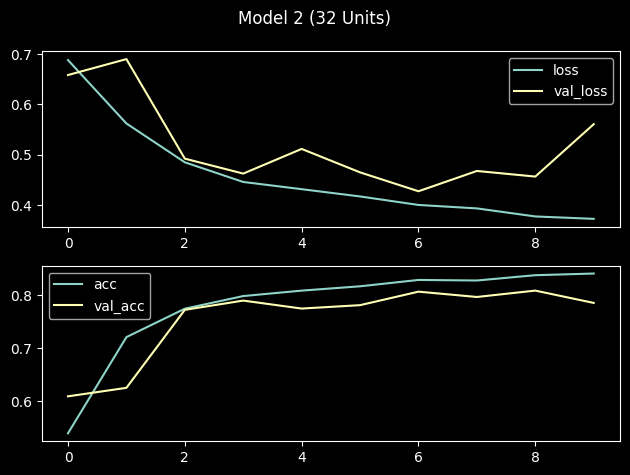

✅ Model 2 Evaluated!


In [4]:
# --- Model 2 ---
print("\n" + "-" * 50)
print("Model 2")
print("-" * 50)

model2 = keras.Sequential([
    layers.Embedding(input_dim=500, output_dim=32),
    layers.SimpleRNN(units=32),  # default activation function is tanh.
    layers.Dense(units=1, activation="sigmoid")
])

model2.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Fit model.
history2 = model2.fit(
    train_x, train_y,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

plot_history(history2, "Model 2 (32 Units)")

# Prediction.
model2.evaluate(train_x, train_y, verbose=0)
model2.evaluate(test_x, test_y, verbose=0)
print("✅ Model 2 Evaluated!")


--------------------------------------------------
Model 3
--------------------------------------------------
Epoch 1/10
157/157 [==============================] - 5s 26ms/step - loss: 0.6680 - accuracy: 0.6090 - val_loss: 0.5528 - val_accuracy: 0.7352
Epoch 2/10
157/157 [==============================] - 4s 24ms/step - loss: 0.5617 - accuracy: 0.7524 - val_loss: 0.4826 - val_accuracy: 0.7814
Epoch 3/10
157/157 [==============================] - 5s 31ms/step - loss: 0.4896 - accuracy: 0.7744 - val_loss: 0.5077 - val_accuracy: 0.7478
Epoch 4/10
157/157 [==============================] - 4s 26ms/step - loss: 0.4799 - accuracy: 0.7977 - val_loss: 0.4902 - val_accuracy: 0.7524
Epoch 5/10
157/157 [==============================] - 4s 24ms/step - loss: 0.4357 - accuracy: 0.8041 - val_loss: 0.4681 - val_accuracy: 0.7804
Epoch 6/10
157/157 [==============================] - 4s 23ms/step - loss: 0.4290 - accuracy: 0.8097 - val_loss: 0.3970 - val_accuracy: 0.8226
Epoch 7/10
157/157 [===========

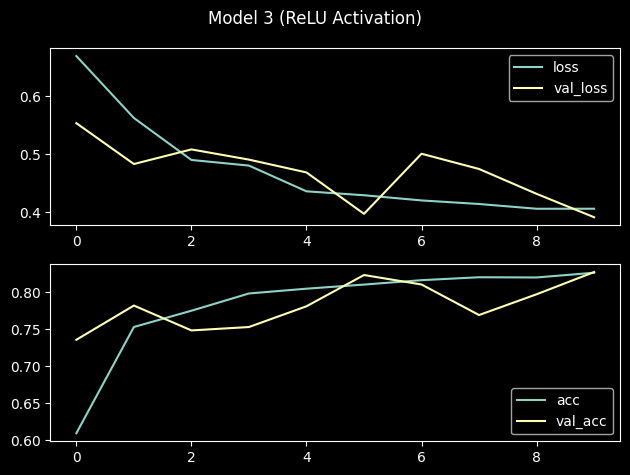

✅ Model 3 Evaluated!


In [5]:
# --- Model 3 ---
print("\n" + "-" * 50)
print("Model 3")
print("-" * 50)

model3 = keras.Sequential([
    layers.Embedding(input_dim=500, output_dim=32),
    layers.SimpleRNN(units=32, activation="relu"),
    layers.Dense(units=1, activation="sigmoid")
])

model3.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Fit model.
history3 = model3.fit(
    train_x, train_y,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

plot_history(history3, "Model 3 (ReLU Activation)")

# Prediction.
model3.evaluate(train_x, train_y, verbose=0)
model3.evaluate(test_x, test_y, verbose=0)
print("✅ Model 3 Evaluated!")


--------------------------------------------------
Model 4
--------------------------------------------------
Epoch 1/10
157/157 [==============================] - 15s 77ms/step - loss: 0.6378 - accuracy: 0.6147 - val_loss: 0.5510 - val_accuracy: 0.7176
Epoch 2/10
157/157 [==============================] - 10s 65ms/step - loss: 0.5353 - accuracy: 0.7359 - val_loss: 0.5030 - val_accuracy: 0.7516
Epoch 3/10
157/157 [==============================] - 12s 75ms/step - loss: 0.4962 - accuracy: 0.7677 - val_loss: 0.5389 - val_accuracy: 0.7386
Epoch 4/10
157/157 [==============================] - 10s 66ms/step - loss: 0.4922 - accuracy: 0.7890 - val_loss: 0.4607 - val_accuracy: 0.7720
Epoch 5/10
157/157 [==============================] - 10s 65ms/step - loss: 0.4445 - accuracy: 0.7995 - val_loss: 0.4623 - val_accuracy: 0.7918
Epoch 6/10
157/157 [==============================] - 10s 66ms/step - loss: 0.4346 - accuracy: 0.8101 - val_loss: 0.4621 - val_accuracy: 0.7918
Epoch 7/10
157/157 [=====

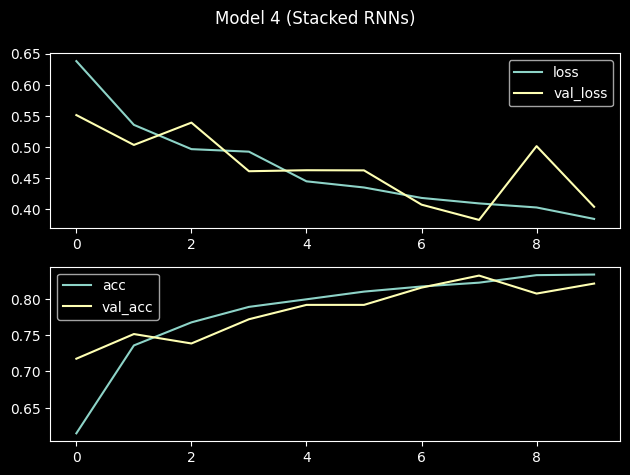

✅ Model 4 Evaluated!


In [6]:
# --- Model 4 ---
print("\n" + "-" * 50)
print("Model 4")
print("-" * 50)

model4 = keras.Sequential([
    layers.Embedding(input_dim=500, output_dim=32),
    layers.SimpleRNN(units=32, return_sequences=True, activation="relu"),
    layers.SimpleRNN(units=32, return_sequences=True, activation="relu"),
    layers.SimpleRNN(units=32, activation="relu"),
    layers.Dense(units=1, activation="sigmoid")
])

model4.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Fit model.
history4 = model4.fit(
    train_x, train_y,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

plot_history(history4, "Model 4 (Stacked RNNs)")

# Prediction.
model4.evaluate(train_x, train_y, verbose=0)
model4.evaluate(test_x, test_y, verbose=0)
print("✅ Model 4 Evaluated!")